# 03 — Entraînement du modèle avec LoRA (QLoRA)

**Objectif :** spécialiser `Qwen2.5-Coder-1.5B-Instruct` sur le Text-to-SQL financier, en n'entraînant qu'une toute petite partie de ses paramètres.

**Rappel de la baseline (notebook 02) :** 58,9 % d'execution accuracy. Le modèle maîtrise la syntaxe SQL (92,4 % de requêtes valides), mais un tiers de ses réponses sont des requêtes valides qui renvoient un mauvais résultat.



## Principe : LoRA et QLoRA

**LoRA** : au lieu de modifier une grande matrice de poids **W** (par exemple 1536 × 1536), on gèle W et on apprend une petite correction **ΔW = B·A**, où A et B ont un rang **r** très petit (ici r = 16).

```
W' = W (gelé)  +  B · A (entraîné)
```

**QLoRA** : en plus, le modèle de base gelé est chargé en **4 bits** au lieu de 16. Il occupe environ 4 fois moins de mémoire GPU, ce qui permet l'entraînement sur un T4 gratuit.

| Hyperparamètre | Valeur | Justification |
|---|---|---|
| `r` | 16 | Bon compromis capacité / nombre de paramètres pour une tâche ciblée |
| `lora_alpha` | 32 | Règle courante : 2 × r |
| `target_modules` | toutes les couches linéaires | Meilleurs résultats que l'attention seule (recommandation de l'article QLoRA) |
| `learning_rate` | 2e-4 | Valeur standard pour LoRA (plus élevée qu'un fine-tuning complet) |
| Epochs | 2 | Suffisant sur quelques milliers d'exemples ; on surveille le surapprentissage avec la validation |
| Batch effectif | 16 | 4 exemples × 4 pas d'accumulation de gradient |

## 0. Installation

In [1]:
import os, sys

REPO_URL = "https://github.com/eya-bouhmida/finance-text2sql-lora"
REPO_DIR = "/content/finance-text2sql-lora"

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL} {REPO_DIR}
    else:
        !cd {REPO_DIR} && git pull
    %cd {REPO_DIR}
    !pip install -q transformers accelerate peft trl bitsandbytes datasets
    sys.path.append(REPO_DIR)
    from google.colab import drive
    drive.mount("/content/drive")
else:
    sys.path.append("..")

DRIVE_DIR = "/content/drive/MyDrive/text2sql-finance-qlora" if IN_COLAB else ".."
DATA_DIR = f"{DRIVE_DIR}/data"
CHECKPOINT_DIR = f"{DRIVE_DIR}/checkpoints/qlora-r16"   # checkpoints sur Drive : survivent aux coupures
ADAPTER_DIR = f"{DRIVE_DIR}/adapters/qlora-r16"         # adaptateur final
RESULTS_DIR = f"{REPO_DIR}/results" if IN_COLAB else "../results"

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 629 bytes | 89.00 KiB/s, done.
From https://github.com/eya-bouhmida/finance-text2sql-lora
   de0dfce..525dccc  main       -> origin/main
Updating de0dfce..525dccc
Fast-forward
 src/train.py | 9 ++++++++-
 1 file changed, 8 insertions(+), 1 deletion(-)
/content/finance-text2sql-lora
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import json, time
import torch
import pandas as pd
import matplotlib.pyplot as plt
from src import data as D, train as T

print("GPU :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "AUCUN (active le GPU T4)")

GPU : Tesla T4


## 1. Chargement des données

In [3]:
train_records = D.load_jsonl(f"{DATA_DIR}/train.jsonl")
val_records = D.load_jsonl(f"{DATA_DIR}/val.jsonl")

train_ds = T.to_prompt_completion(train_records)
val_ds = T.to_prompt_completion(val_records)
print(f"Train : {len(train_ds)} | Validation : {len(val_ds)}")
train_ds[0]

Train : 2806 | Validation : 312


{'prompt': [{'content': 'You are an expert SQL assistant for financial databases. Given a database schema and a question, write a single SQLite query that answers it. Return only the SQL query.',
   'role': 'system'},
  {'content': '### Schema:\nCREATE TABLE social_impact_investments (id INT, country VARCHAR(50), transaction_value FLOAT);\n\n### Question:\nWhat is the maximum transaction value for social impact investments in the United Kingdom?',
   'role': 'user'}],
 'completion': [{'content': "SELECT MAX(transaction_value) FROM social_impact_investments WHERE country = 'United Kingdom';",
   'role': 'assistant'}]}

## 2. Chargement du modèle en 4 bits

In [4]:
torch.cuda.reset_peak_memory_stats()
model, tokenizer = T.load_quantized_model(T.BASE_MODEL)
print(f"Mémoire GPU après chargement en 4 bits : {torch.cuda.memory_allocated() / 1e9:.2f} Go")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Mémoire GPU après chargement en 4 bits : 1.15 Go


### 2.1 Vérification de la longueur des exemples

Les exemples plus longs que `max_length` (1024 tokens) seraient tronqués, et le modèle apprendrait des requêtes coupées. On vérifie qu'aucun exemple ne dépasse cette limite.

In [5]:
lengths = [
    len(tokenizer(tokenizer.apply_chat_template(r["messages"], tokenize=False))["input_ids"])
    for r in train_records
]
lengths = pd.Series(lengths)
print(f"Longueur en tokens — médiane : {lengths.median():.0f} | 95e percentile : {lengths.quantile(0.95):.0f} | max : {lengths.max()}")
print(f"Exemples > {T.TRAINING_DEFAULTS['max_length']} tokens : {(lengths > T.TRAINING_DEFAULTS['max_length']).sum()}")

Longueur en tokens — médiane : 125 | 95e percentile : 180 | max : 310
Exemples > 1024 tokens : 0


## 3. Configuration LoRA et de l'entraînement

In [6]:
lora_config = T.make_lora_config()          # valeurs par défaut de src/train.py
training_args = T.make_training_args(CHECKPOINT_DIR)

trainer = T.build_trainer(model, tokenizer, train_ds, val_ds, lora_config, training_args)
trainer.model.print_trainable_parameters()

Tokenizing train dataset:   0%|          | 0/2806 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/2806 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/2806 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/2806 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/312 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/312 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/312 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/312 [00:00<?, ? examples/s]

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


In [7]:
trainable = sum(p.numel() for p in trainer.model.parameters() if p.requires_grad)
total = sum(p.numel() for p in trainer.model.parameters())
print(f"Paramètres entraînés : {trainable:,} sur {total:,} ({100 * trainable / total:.2f} %)")

Paramètres entraînés : 18,464,768 sur 907,081,216 (2.04 %)


## 4. Entraînement

Les checkpoints sont sauvegardés sur Google Drive toutes les 50 étapes. **Si Colab coupe la session**, il suffit de tout réexécuter : l'entraînement reprend automatiquement au dernier checkpoint.

In [8]:
resume = T.latest_checkpoint(CHECKPOINT_DIR)
print("Reprise depuis :", resume or "début (aucun checkpoint)")

start = time.time()
train_output = trainer.train(resume_from_checkpoint=resume)
train_minutes = (time.time() - start) / 60

print(f"\nDurée : {train_minutes:.1f} min")
print(f"Pic de mémoire GPU : {torch.cuda.max_memory_allocated() / 1e9:.2f} Go")

Reprise depuis : début (aucun checkpoint)


Step,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
50,0.192834,0.200084,0.185112,0.936702,104758.000000
100,0.186851,0.177197,0.170351,0.944650,207727.000000
150,0.157433,0.165026,0.166502,0.946428,311872.000000
200,0.103350,0.158185,0.133371,0.950428,415472.000000
250,0.109840,0.158030,0.122803,0.949693,519461.000000
300,0.094699,0.156125,0.118955,0.951277,624724.000000
350,0.110387,0.154003,0.117378,0.951668,728830.000000
352,0.110387,0.153986,0.117375,0.951949,731544.000000



Durée : 18.5 min
Pic de mémoire GPU : 1.65 Go


## 5. Courbes d'apprentissage

- La **loss d'entraînement** doit baisser.
- La **loss de validation** doit baisser aussi, puis se stabiliser. Si elle remonte alors que la loss d'entraînement continue de baisser, c'est du **surapprentissage** : le modèle apprend par cœur. Grâce à `load_best_model_at_end`, on garde automatiquement le checkpoint avec la meilleure loss de validation.

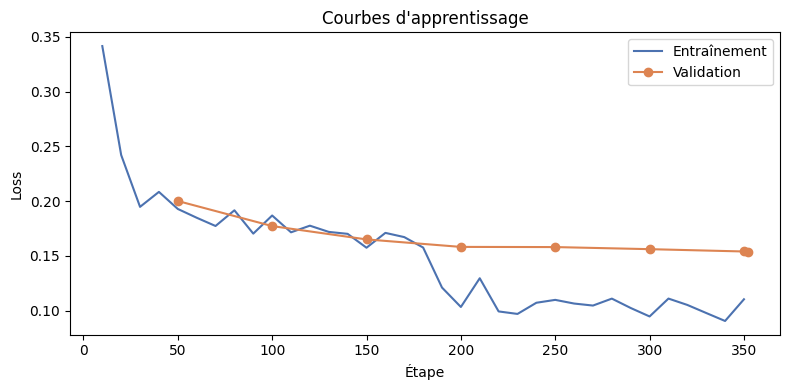

Meilleure loss de validation : 0.1540 (/content/drive/MyDrive/text2sql-finance-qlora/checkpoints/qlora-r16/checkpoint-352)


In [9]:
logs = pd.DataFrame(trainer.state.log_history)
train_loss = logs.dropna(subset=["loss"])[["step", "loss"]]
eval_loss = logs.dropna(subset=["eval_loss"])[["step", "eval_loss"]]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_loss["step"], train_loss["loss"], label="Entraînement", color="#4C72B0")
ax.plot(eval_loss["step"], eval_loss["eval_loss"], label="Validation", color="#DD8452", marker="o")
ax.set_xlabel("Étape"); ax.set_ylabel("Loss"); ax.set_title("Courbes d'apprentissage")
ax.legend(); plt.tight_layout()
os.makedirs(RESULTS_DIR, exist_ok=True)
plt.savefig(f"{RESULTS_DIR}/03_learning_curves.png", dpi=150)
plt.show()

print(f"Meilleure loss de validation : {trainer.state.best_metric:.4f} ({trainer.state.best_model_checkpoint})")

## 6. Sauvegarde de l'adaptateur

In [10]:
trainer.model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

adapter_mb = T.dir_size_mb(ADAPTER_DIR)
print(f"Adaptateur sauvegardé dans {ADAPTER_DIR}")
print(f"Taille de l'adaptateur : {adapter_mb} Mo (contre environ 3 000 Mo pour le modèle complet en float16)")

Adaptateur sauvegardé dans /content/drive/MyDrive/text2sql-finance-qlora/adapters/qlora-r16
Taille de l'adaptateur : 85.3 Mo (contre environ 3 000 Mo pour le modèle complet en float16)


In [11]:
# Résumé de l'entraînement, versionné dans results/ pour le README et le notebook 04
training_summary = {
    "base_model": T.BASE_MODEL,
    "method": "QLoRA (4-bit NF4)",
    "lora": {k: v for k, v in T.LORA_DEFAULTS.items()},
    "training": {k: T.TRAINING_DEFAULTS[k] for k in
                 ["num_train_epochs", "learning_rate", "per_device_train_batch_size",
                  "gradient_accumulation_steps", "max_length"]},
    "n_train": len(train_ds),
    "n_val": len(val_ds),
    "trainable_params": trainable,
    "total_params": total,
    "trainable_pct": round(100 * trainable / total, 3),
    "train_minutes": round(train_minutes, 1),
    "peak_gpu_gb": round(torch.cuda.max_memory_allocated() / 1e9, 2),
    "adapter_mb": adapter_mb,
    "best_eval_loss": round(trainer.state.best_metric, 4),
}
with open(f"{RESULTS_DIR}/03_training_summary.json", "w") as f:
    json.dump(training_summary, f, indent=2)
logs.to_csv(f"{RESULTS_DIR}/03_training_logs.csv", index=False)
pd.Series(training_summary)

,0
base_model,Qwen/Qwen2.5-Coder-1.5B-Instruct
method,QLoRA (4-bit NF4)
lora,"{'r': 16, 'lora_alpha': 32, 'lora_dropout': 0...."
training,"{'num_train_epochs': 2, 'learning_rate': 0.000..."
n_train,2806
n_val,312
trainable_params,18464768
total_params,907081216
trainable_pct,2.036
train_minutes,18.5


## 7. Premier essai du modèle fine-tuné

Un rapide test sur quelques questions de **validation**, pour vérifier que le modèle produit bien du SQL. L'évaluation complète sur le jeu de test se fait dans le notebook 04, avec exactement la même procédure que la baseline.

In [12]:
from src import model as M, evaluate as E

tokenizer.padding_side = "left"     # nécessaire pour la génération
trainer.model.config.use_cache = True
trainer.model.eval()

samples = val_records[:5]
prompts = [r["messages"][:-1] for r in samples]   # sans la réponse
outputs, _ = M.generate(trainer.model, tokenizer, prompts)

for r, out in zip(samples, outputs):
    pred = E.extract_sql(out)
    ok = E.evaluate_one(r["context"], r["gold_sql"], pred)["execution_match"]
    print(f"QUESTION  : {r['question']}")
    print(f"RÉFÉRENCE : {r['gold_sql']}")
    print(f"MODÈLE    : {pred}")
    print(f"Correct   : {'✅' if ok else '❌'}\n" + "-" * 80)

5/5
QUESTION  : Find the total premium for motorcycle policies in Florida.
RÉFÉRENCE : SELECT SUM(policyholders.premium) FROM policyholders WHERE policyholders.state = 'Florida' AND policyholders.policy_type = 'Motorcycle';
MODÈLE    : SELECT SUM(premium) FROM policyholders WHERE policy_type = 'Motorcycle' AND state = 'FL';
Correct   : ❌
--------------------------------------------------------------------------------
QUESTION  : Calculate the average financial wellbeing score for women in Southeast Asia.
RÉFÉRENCE : SELECT AVG(score) FROM financial_wellbeing WHERE country LIKE 'Southeast%' AND gender = 'Female';
MODÈLE    : SELECT AVG(score) FROM financial_wellbeing WHERE gender = 'Female' AND country LIKE 'Southeast%';
Correct   : ✅
--------------------------------------------------------------------------------
QUESTION  : Find the sum of investments for projects with a climate action focus in the Asia-Pacific region.
RÉFÉRENCE : SELECT SUM(investment) FROM projects_investments WHERE

## Conclusion de l'entraînement

## Conclusion de l'entraînement

- Seulement **≈ 18,5 millions de paramètres** ont été entraînés, soit **≈ 1,2 %** des 1,54 milliard de paramètres du modèle (le pourcentage affiché par la bibliothèque, 2,04 %, est faussé par le stockage 4 bits qui compte deux poids par élément).
- L'entraînement a pris **18,5 minutes** sur un GPU T4 gratuit, avec un pic de **1,65 Go** de mémoire GPU.
- L'adaptateur pèse **85,3 Mo**, contre environ 3 Go pour le modèle complet.
- **Courbes d'apprentissage :** pas de sous-apprentissage. Pendant la première epoch, les losses d'entraînement et de validation baissent ensemble (de 0,34 à ≈ 0,16). Au début de la deuxième epoch (≈ étape 180), la loss d'entraînement chute à ≈ 0,10 alors que la validation se stabilise (≈ 0,155) : le modèle commence à mémoriser les exemples déjà vus. La validation ne remonte pas, il n'y a donc pas de surapprentissage nuisible, mais une epoch supplémentaire n'apporterait probablement rien. Le meilleur checkpoint (validation la plus basse) a été conservé.

**Prochaine étape :** notebook 04, évaluation sur le jeu de test et comparaison avec la baseline.